## Generating base dataset from plain chart files

In [69]:
import glob
import re
from enum import IntEnum
from pathlib import Path
from typing import Annotated, Literal
import sqlite3

from pydantic import BaseModel, Field

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns


class SlidePattern(IntEnum):
    no_slide = 0
    straight = 1
    ccw_edge = 2
    cw_edge = 3
    ccw_centre_arc = 4
    cw_centre_arc = 5
    zigzag_s = 6
    zigzag_z = 7
    straight_centre_end = 8
    straight_centre_ccw_end = 9
    straight_centre_cw_end = 10
    ccw_grand_v = 11
    cw_grand_v = 12
    fan = 13


class ChartDifficulty(IntEnum):
    easy = 1
    basic = 2
    advanced = 3
    expert = 4
    master = 5
    re_master = 6


class SDTRowWithMetadata(BaseModel):
    whole_measure: int = Field(ge=0)
    fractional_measure: float = Field(ge=0, le=1) # SCT Can have this as 1, look into this
    duration: float = Field(ge=0)
    location: int = Literal[0, 1, 2, 3, 4, 5, 6, 7]
    note_type: int = Literal[0, 1, 2, 3, 4, 5, 128]
    slide_id: int = Field(ge=0)
    slide_pattern: SlidePattern
    slide_amount: int = Field(ge=0)
    slide_delay: float = Field(ge=0)

    difficulty: ChartDifficulty
    bpm: float | None


class SlideParams(BaseModel):
    star_duration: float = Field(ge=0)
    slide_duration: float = Field(ge=0)
    slide_delay: float = Field(ge=0)
    distance: int = Literal[0, 1, 2, 3, 4, 5, 6, 7, 8]
    # end: int = Literal[0, 1, 2, 3, 4, 5, 6, 7]
    slide_pattern: SlidePattern
    bpm: float | None
    difficulty: ChartDifficulty
    version: str


def get_clockwise_slide_distance(start_location: int, end_location: int) -> int:
    return abs(start_location - end_location)


def get_counter_clockwise_slide_distance(start_location: int, end_location: int) -> int:
    return 7 - abs(start_location - end_location)


def get_shortest_slide_distance(start_location: int, end_location: int) -> int:
    return min(
        get_clockwise_slide_distance(start_location, end_location),
        get_counter_clockwise_slide_distance(start_location, end_location)
    )


def get_distance_for_slide(start_location: int, end_location: int, slide_pattern: SlidePattern) -> int:
    match slide_pattern.value:
        case SlidePattern.no_slide.value:
            raise ValueError('`no_slide` cannot be used to calculate slide distance.')

        case SlidePattern.straight.value:
            return get_shortest_slide_distance(start_location, end_location)

        case SlidePattern.ccw_edge.value:
            return get_counter_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.cw_edge.value:
            return get_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.ccw_centre_arc.value:
            return get_counter_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.cw_centre_arc.value:
            return get_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.zigzag_s.value | SlidePattern.zigzag_z.value:
            return get_shortest_slide_distance(start_location, end_location)

        case SlidePattern.straight_centre_end.value:
            return get_shortest_slide_distance(start_location, end_location)

        case SlidePattern.straight_centre_ccw_end.value:
            return get_counter_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.straight_centre_cw_end.value:
            return get_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.ccw_grand_v.value:
            return get_counter_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.cw_grand_v.value:
            return get_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.fan.value:
            return get_shortest_slide_distance(start_location, end_location)

    raise ValueError(f'Unrecognized slide pattern_group type {slide_pattern} {type(slide_pattern)}.')


# Exclude utage chart files, and exclude SRT
plain_non_utage_charts = glob.glob("plain charts/*_0[123456]*.s[cdz]t")

# sdt_pattern = re.compile(r"")
df = pd.DataFrame(columns=["star_duration", "slide_duration", "distance", "slide_pattern", "difficulty", "version"])

notes: list[SDTRowWithMetadata] = []

slide_params: list[SlideParams] = []


with sqlite3.connect('table_data.sqlite') as conn:
    for chart in plain_non_utage_charts:
        chart_difficulty = int(chart_path.stem.split("_")[-1])
        song_id = int(chart_path.stem.split("_")[0])
        # print(chart_path.stem)
        # print(song_id)
        chart_bpm = conn.execute("""SELECT bpm FROM song WHERE id = ?;""", (song_id,)).fetchone()

        if chart_bpm:
            chart_bpm = chart_bpm[0]

        chart_path = Path(chart)
        with open(chart_path, "r") as f:
            chart_lines = f.readlines()
            # Get all components of the chart, remove whitespace and empty sets from blank lines
            chart_component_sets = [
                [str.strip(component) for component in chart_line.split(',') if str.strip(component)]
                for chart_line in chart_lines if str.strip(chart_line)
            ]

            rows = []

            chart_version = chart_path.suffix[1:]
            chart_difficulty = int(chart_path.stem.split("_")[-1])

            match chart_path.suffix:
                case ".sdt":
                    rows = [SDTRowWithMetadata(whole_measure=row[0], fractional_measure=row[1], duration=row[2], location=row[3],
                                               note_type=row[4],
                                               slide_id=row[5], slide_pattern=row[6], slide_amount=row[7], slide_delay=row[8],
                                               difficulty=chart_difficulty, bpm=chart_bpm)
                            for row in chart_component_sets]

                case ".sct":
                    rows = [SDTRowWithMetadata(whole_measure=row[0], fractional_measure=row[1], duration=row[2], location=row[3],
                                               note_type=row[4],
                                               slide_id=row[5], slide_pattern=row[6], slide_amount=row[7], slide_delay=0.25,
                                               difficulty=chart_difficulty, bpm=chart_bpm)
                            for row in chart_component_sets]

                case ".szt":
                    rows = [SDTRowWithMetadata(whole_measure=row[0], fractional_measure=row[1], duration=row[2], location=row[3],
                                               note_type=row[4],
                                               slide_id=row[5], slide_pattern=row[6], slide_amount=1, slide_delay=0.25,
                                               difficulty=chart_difficulty, bpm=chart_bpm)
                            for row in chart_component_sets]

            for potential_star in rows:
                if potential_star.note_type == 4 or potential_star.note_type == 5:
                    slides_param_sets: list[SlideParams] = []

                    slides = [i for i in rows if i.note_type == 0
                              and i.whole_measure == potential_star.whole_measure
                              and i.fractional_measure == potential_star.fractional_measure]

                    for slide in slides:
                        end_slide = [i for i in rows if i.note_type == 128 and i.slide_id == slide.slide_id]
                        # Each start slide should have only one end slide
                        assert len(end_slide) == 1

                        end_slide = end_slide[0]

                        slides_param_sets.append(SlideParams(
                            star_duration=potential_star.duration,
                            slide_duration=slide.duration,
                            distance=get_clockwise_slide_distance(
                                potential_star.location, end_slide.location
                            ),
                            slide_pattern=slide.slide_pattern,
                            version=chart_version,
                            slide_delay=slide.slide_delay,

                            difficulty=potential_star.difficulty,
                            bpm=potential_star.bpm
                        ))

                    slide_params.extend(slides_param_sets)

                notes.extend(rows)

# Get all slides found in the game as a single dataframe
full_df = pd.DataFrame(
    data=[
        [params.star_duration, params.slide_duration, params.slide_delay, params.distance,
         params.slide_pattern, params.bpm, params.difficulty, params.version]
        for params in slide_params],
    columns=["star_duration", "slide_duration", "slide_delay", "distance", "pattern_group", "bpm", "difficulty", "version"]
)
# Remove duplicates to find patterns between different configurations over huge groups of identical slide
pruned_df = full_df.drop_duplicates()

pruned_df['duration_ratio']            = pruned_df['star_duration'] / pruned_df['slide_duration']
pruned_df['duration_with_delay']       = pruned_df['slide_duration'] + pruned_df['slide_delay']
pruned_df['duration_with_delay_ratio'] = pruned_df['star_duration'] / pruned_df['duration_with_delay']

pruned_df

,star_duration,slide_duration,slide_delay,distance,pattern_group,bpm,difficulty,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,0.7500,1.000,0.25,3,1,172.0,1,sdt,0.750000,1.250,0.600000
2,0.1157,0.375,0.25,4,1,169.3,6,sdt,0.308533,0.625,0.185120
4,0.1250,0.375,0.25,3,1,169.3,6,sdt,0.333333,0.625,0.200000
5,0.0980,0.500,0.25,6,2,169.3,6,sdt,0.196000,0.750,0.130667
6,0.0977,0.375,0.25,3,3,169.3,6,sdt,0.260533,0.625,0.156320
...,...,...,...,...,...,...,...,...,...,...,...
111500,0.3521,1.000,0.25,3,3,135.0,3,sdt,0.352100,1.250,0.281680
111501,0.3906,0.750,0.25,5,2,135.0,3,sdt,0.520800,1.000,0.390600
111502,0.3906,0.750,0.25,4,3,135.0,3,sdt,0.520800,1.000,0.390600
111503,0.3906,0.750,0.25,4,2,135.0,3,sdt,0.520800,1.000,0.390600


### Finding percentage of rows with no BPM value

In [46]:
100 * pruned_df['bpm'].isnull().sum() / len(pruned_df.index)

# pruned_df['bpm'] / pruned_df.groupby('bpm')['bpm'].transform('sum')


np.float64(4.260536811469225)

In [70]:
outlier_removed_df = pruned_df[np.abs(stats.zscore(pruned_df['star_duration'])) < 3]

outlier_removed_df

,star_duration,slide_duration,slide_delay,distance,pattern_group,bpm,difficulty,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,0.7500,1.000,0.25,3,1,172.0,1,sdt,0.750000,1.250,0.600000
2,0.1157,0.375,0.25,4,1,169.3,6,sdt,0.308533,0.625,0.185120
4,0.1250,0.375,0.25,3,1,169.3,6,sdt,0.333333,0.625,0.200000
5,0.0980,0.500,0.25,6,2,169.3,6,sdt,0.196000,0.750,0.130667
6,0.0977,0.375,0.25,3,3,169.3,6,sdt,0.260533,0.625,0.156320
...,...,...,...,...,...,...,...,...,...,...,...
111500,0.3521,1.000,0.25,3,3,135.0,3,sdt,0.352100,1.250,0.281680
111501,0.3906,0.750,0.25,5,2,135.0,3,sdt,0.520800,1.000,0.390600
111502,0.3906,0.750,0.25,4,3,135.0,3,sdt,0.520800,1.000,0.390600
111503,0.3906,0.750,0.25,4,2,135.0,3,sdt,0.520800,1.000,0.390600


### Defining colour palette for difficulty aggregation

In [47]:
difficulty_colours = {
    1: '#00afff',
    2: '#00e800',
    3: '#ff9400',
    4: '#ff0519',
    5: '#b300ff',
    6: '#f6c9ff',
}

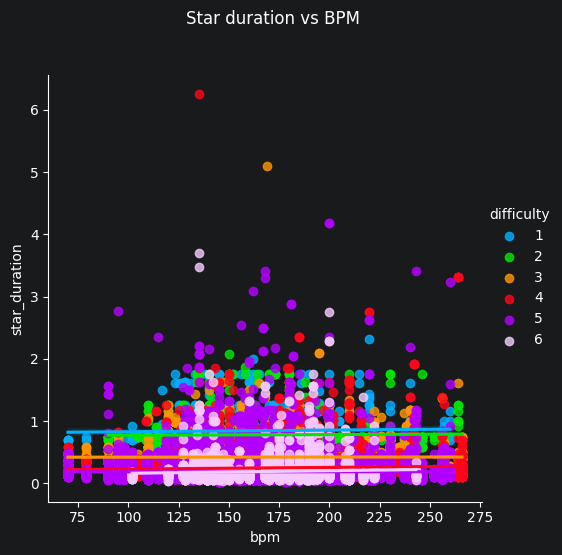

In [54]:
plot = sns.lmplot(data=outlier_removed_df, x="bpm", y="star_duration", hue="difficulty", palette=difficulty_colours)
plot.figure.suptitle('Star duration vs BPM', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## Looking for simple correlations between star duration and slide duration (with / without delay)

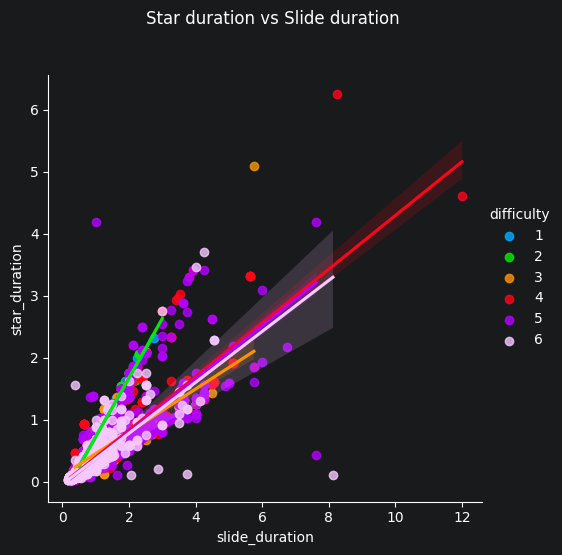

In [62]:
plot = sns.lmplot(data=outlier_removed_df, x="slide_duration", y="star_duration", hue="difficulty", palette=difficulty_colours)
plot.figure.suptitle('Star duration vs Slide duration', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

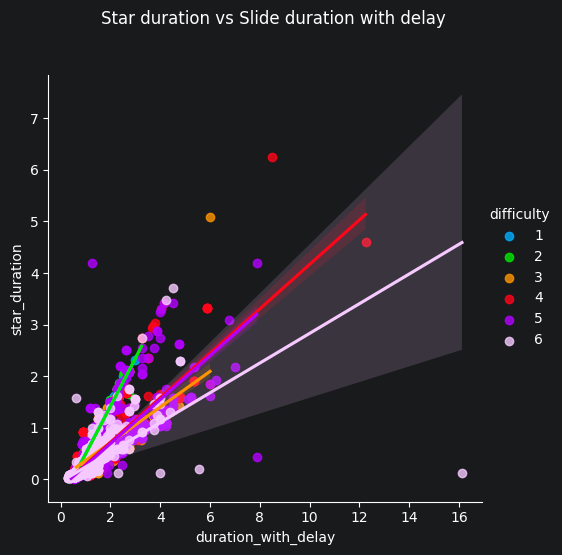

In [59]:
plot = sns.lmplot(data=outlier_removed_df, x="duration_with_delay", y="star_duration", hue="difficulty", palette=difficulty_colours)
plot.figure.suptitle('Star duration vs Slide duration with delay', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

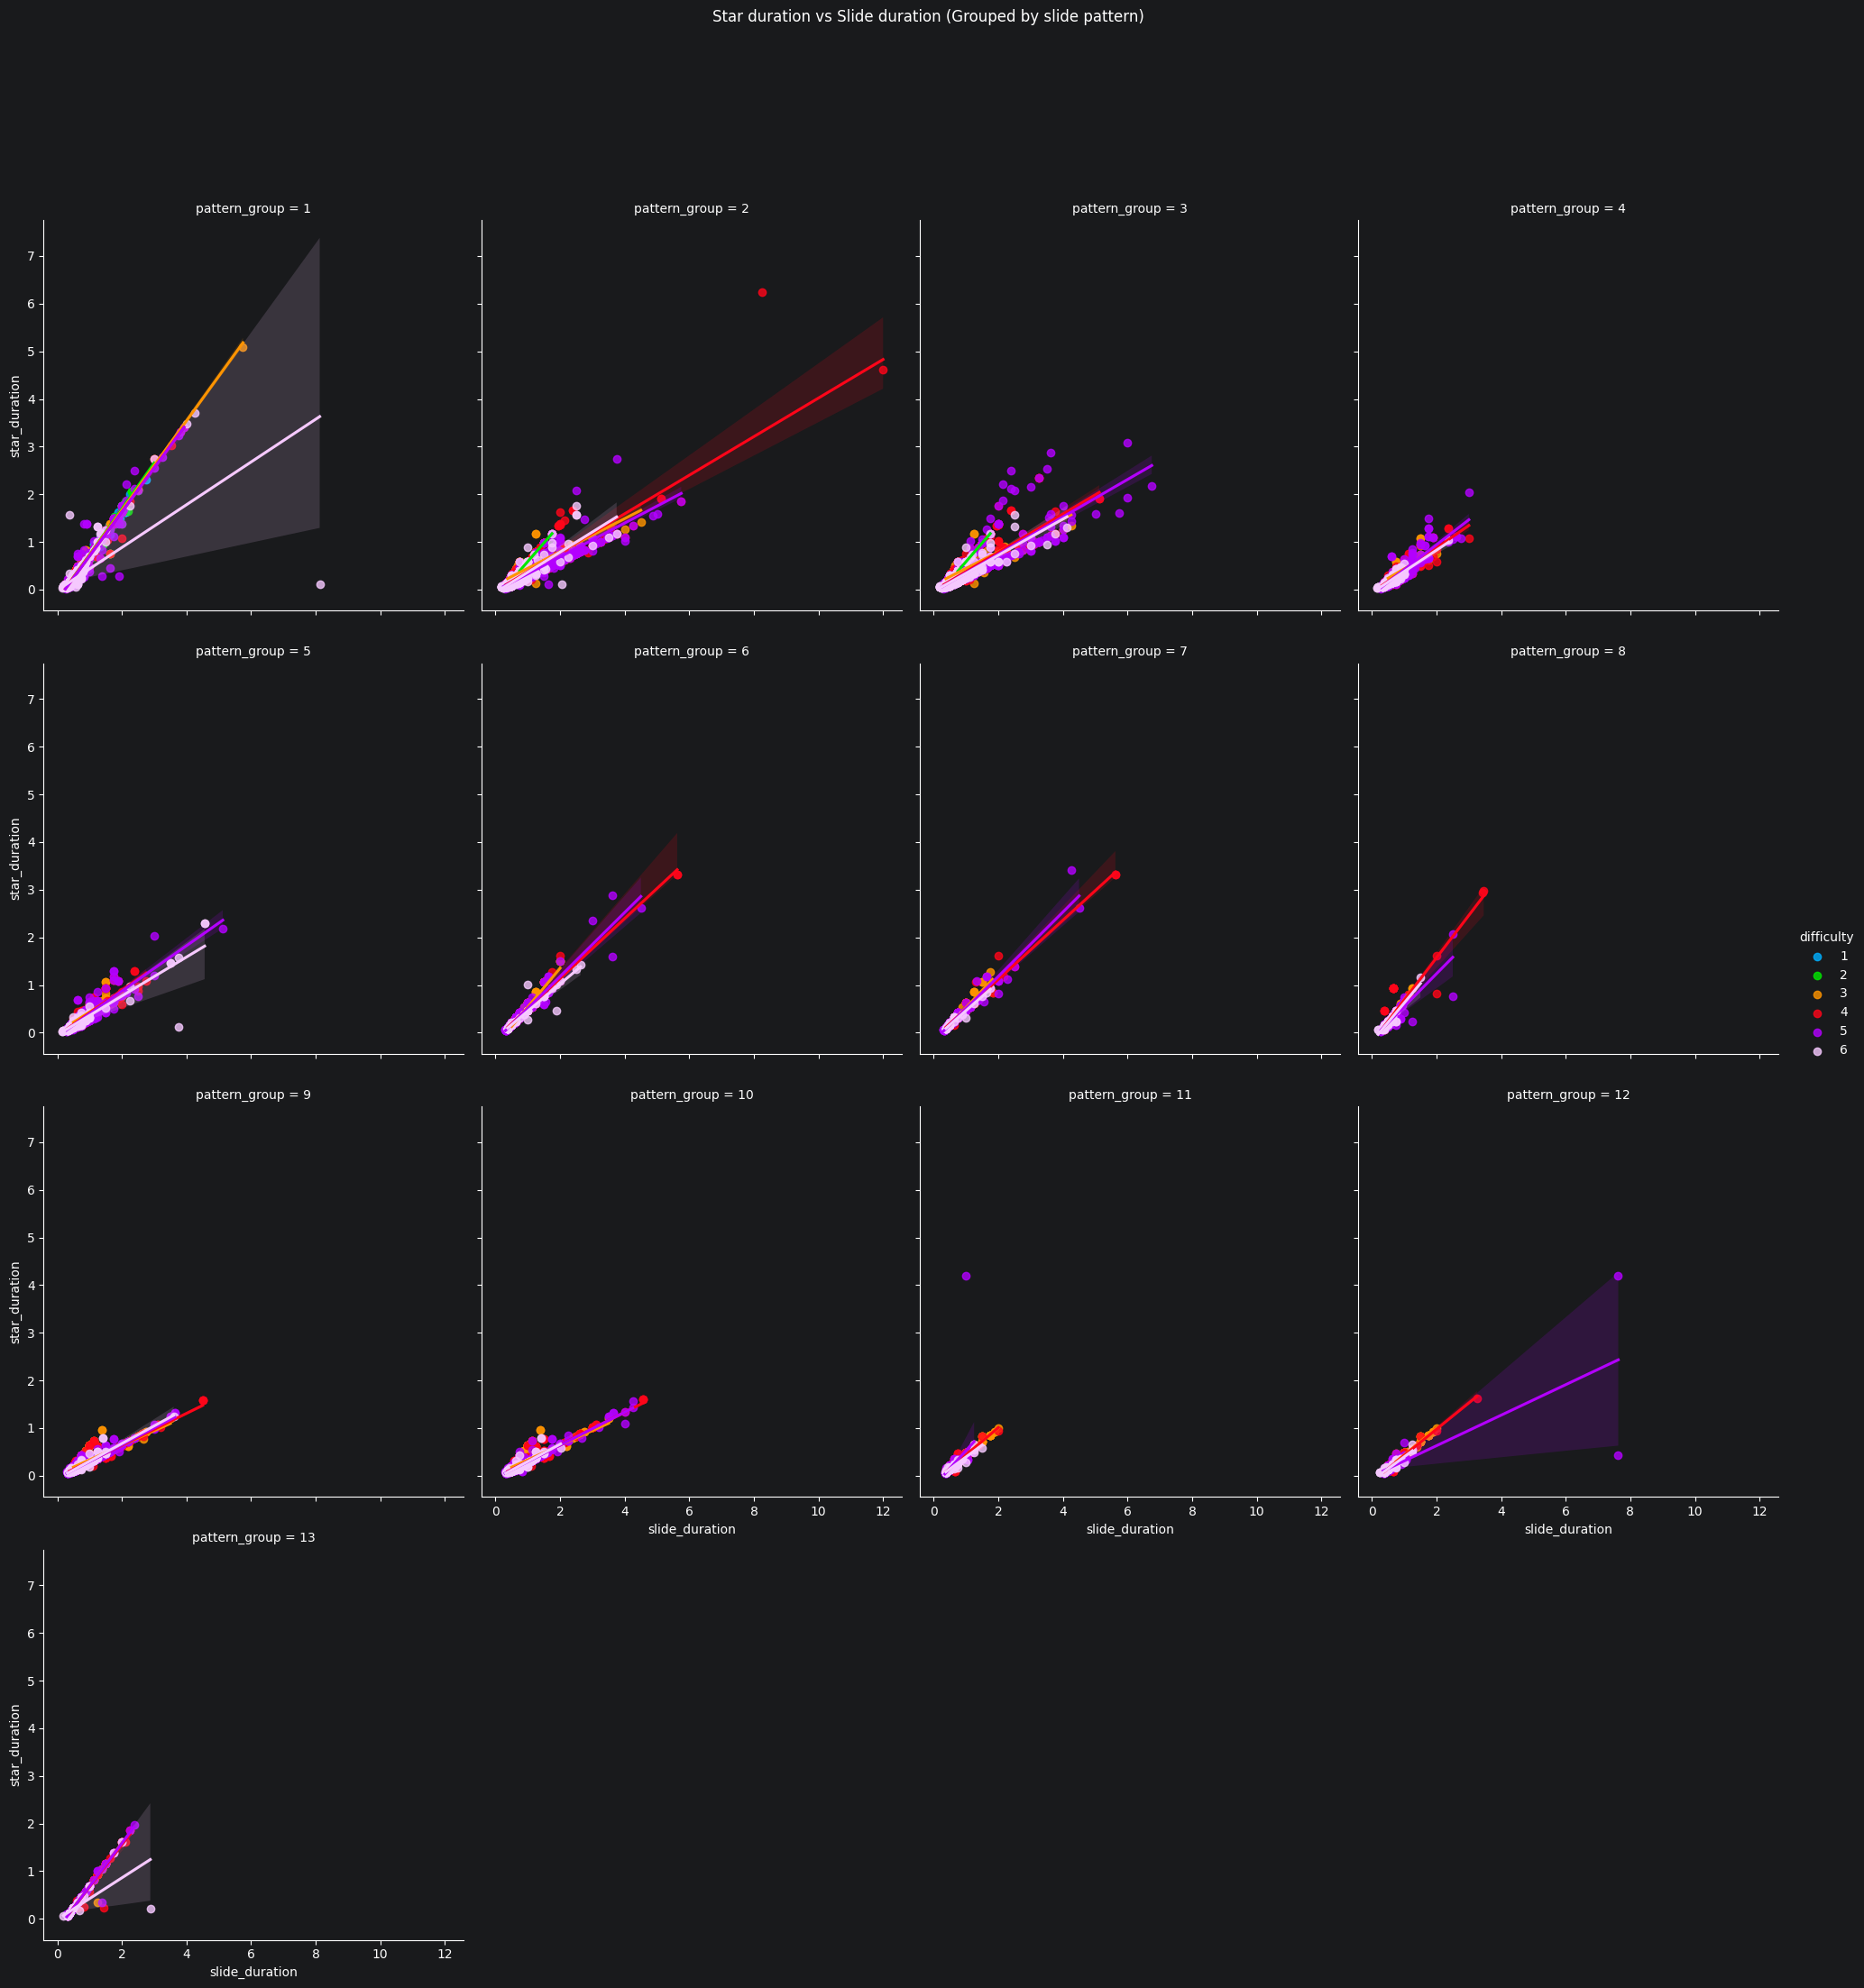

In [72]:
plot = sns.lmplot(data=outlier_removed_df, x="slide_duration", y="star_duration", hue="difficulty", col='pattern_group', col_wrap=4,palette=difficulty_colours)
plot.figure.suptitle('Star duration vs Slide duration (Grouped by slide pattern)', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## Preparing data for averages by pattern, distance and difficulty

In [27]:
# Group by pattern and difficulty for filtering (since that represents a single bar for the next cell)
groups = pruned_df.groupby(['pattern_group', 'difficulty'])
# Only include data within 3 standard deviations of the mean
star_spin_without_delay_ratio_df_bar_outliers = groups.apply(lambda group: group[np.abs(stats.zscore(group['duration_ratio'])) < 3]).reset_index()

star_spin_without_delay_ratio_df_bar_outliers

,pattern_group,difficulty,level_2,star_duration,slide_duration,slide_delay,distance,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,1,1,0,0.750000,1.000000,0.2500,3,sdt,0.750000,1.250000,0.600000
1,1,1,504,0.694445,1.000000,0.2500,4,sct,0.694445,1.250000,0.555556
2,1,1,506,0.694446,1.000002,0.2500,4,sct,0.694445,1.250002,0.555556
3,1,1,507,0.694444,1.000000,0.2500,4,sct,0.694444,1.250000,0.555555
4,1,1,508,0.694449,1.000000,0.2500,4,sct,0.694449,1.250000,0.555559
...,...,...,...,...,...,...,...,...,...,...,...
14530,13,6,59773,0.477600,0.810600,0.2948,4,sdt,0.589193,1.105400,0.432061
14531,13,6,91751,0.347200,0.625000,0.2500,4,sdt,0.555520,0.875000,0.396800
14532,13,6,92170,1.620370,1.999996,0.2500,4,sct,0.810187,2.249996,0.720166
14533,13,6,94746,0.115738,0.375000,0.2500,4,sct,0.308635,0.625000,0.185181


In [28]:
# Only include data within 3 standard deviations of the mean
star_spin_with_delay_ratio_df_bar_outliers = groups.apply(lambda group: group[np.abs(stats.zscore(group['duration_with_delay_ratio'])) < 3]).reset_index()

star_spin_with_delay_ratio_df_bar_outliers

,pattern_group,difficulty,level_2,star_duration,slide_duration,slide_delay,distance,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,1,1,0,0.750000,1.000000,0.2500,3,sdt,0.750000,1.250000,0.600000
1,1,1,504,0.694445,1.000000,0.2500,4,sct,0.694445,1.250000,0.555556
2,1,1,506,0.694446,1.000002,0.2500,4,sct,0.694445,1.250002,0.555556
3,1,1,507,0.694444,1.000000,0.2500,4,sct,0.694444,1.250000,0.555555
4,1,1,508,0.694449,1.000000,0.2500,4,sct,0.694449,1.250000,0.555559
...,...,...,...,...,...,...,...,...,...,...,...
14463,13,6,59773,0.477600,0.810600,0.2948,4,sdt,0.589193,1.105400,0.432061
14464,13,6,91751,0.347200,0.625000,0.2500,4,sdt,0.555520,0.875000,0.396800
14465,13,6,92170,1.620370,1.999996,0.2500,4,sct,0.810187,2.249996,0.720166
14466,13,6,94746,0.115738,0.375000,0.2500,4,sct,0.308635,0.625000,0.185181


In [29]:
star_spin_ratio_normalised_df_bar_outliers = groups.apply(lambda group: group[np.abs(stats.zscore(group['duration_ratio'])) < 3]).reset_index()

star_spin_ratio_normalised_df_bar_outliers = star_spin_ratio_normalised_df_bar_outliers.loc[star_spin_ratio_normalised_df_bar_outliers['star_duration'] == 1]

star_spin_ratio_normalised_df_bar_outliers

,pattern_group,difficulty,level_2,star_duration,slide_duration,slide_delay,distance,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
16,1,1,5414,1.0,1.250000,0.25,3,sdt,0.800000,1.500000,0.666667
21,1,1,6636,1.0,1.250000,0.25,3,szt,0.800000,1.500000,0.666667
22,1,1,6642,1.0,1.250000,0.25,3,sct,0.800000,1.500000,0.666667
64,1,1,23961,1.0,1.249996,0.25,3,sct,0.800003,1.499996,0.666668
65,1,1,23962,1.0,1.250004,0.25,3,sct,0.799997,1.500004,0.666665
92,1,1,37562,1.0,1.250000,0.25,5,sdt,0.800000,1.500000,0.666667
117,1,1,59060,1.0,1.250002,0.25,3,sct,0.799999,1.500002,0.666666
151,1,1,95485,1.0,1.250000,0.25,4,szt,0.800000,1.500000,0.666667
208,1,2,11201,1.0,1.250000,0.25,5,szt,0.800000,1.500000,0.666667
209,1,2,11203,1.0,1.250000,0.25,3,szt,0.800000,1.500000,0.666667


In [32]:
correlatable_df = pruned_df.drop(axis=1, labels=['version'])

correlatable_df.corrwith(correlatable_df['star_duration'])

star_duration                1.000000
slide_duration               0.007299
slide_delay                 -0.000398
distance                     0.001099
pattern_group               -0.012143
difficulty                  -0.035584
duration_ratio               0.999998
duration_with_delay          0.007052
duration_with_delay_ratio    0.999998
dtype: float64

## Defining slide patterns that are similar to one another

In [ ]:
pattern_groups: tuple[tuple[str, tuple[SlidePattern, ...]], ...] = (
    ('Straight Line', (SlidePattern.straight,)),
    ('Edge Circle', (SlidePattern.cw_edge, SlidePattern.ccw_edge)),
    ('Centre Arc', (SlidePattern.cw_centre_arc, SlidePattern.ccw_centre_arc)),
    ('Zigzag', (SlidePattern.zigzag_s, SlidePattern.zigzag_z)),
    ('Straight - Centre - End', (SlidePattern.straight_centre_end,)),
    ('Straight - Arc - End', (SlidePattern.straight_centre_ccw_end, SlidePattern.straight_centre_cw_end)),
    ('Grand V', (SlidePattern.ccw_grand_v, SlidePattern.cw_grand_v)),
    ('Fan', (SlidePattern.fan,))
)

In [ ]:
# sns.color_palette(difficulty_colours)

duration_at_one_star_duration_bar_fig, duration_at_one_star_bar_axs = plt.subplots(ncols=4, nrows=4)
duration_at_one_star_duration_bar_fig.suptitle('TODO', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for distance correct?)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_without_delay_ratio_df_bar_outliers.loc[star_spin_without_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="distance", y="slide_duration", hue="difficulty", palette=difficulty_colours,
                       ax=duration_at_one_star_bar_axs[count // 4][count % 4]).set(title=pattern_group.name)

duration_at_one_star_duration_bar_fig.set_size_inches(30, 30)

duration_at_one_star_duration_bar_fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## Visualising slides by pattern, distance and difficulty

In [ ]:
difficulty_colours = {
    1: '#00afff',
    2: '#00e800',
    3: '#ff9400',
    4: '#ff0519',
    5: '#b300ff',
    6: '#f6c9ff',
}

# sns.color_palette(difficulty_colours)

duration_ratio_bar_fig, duration_bar_axs = plt.subplots(ncols=4, nrows=4)
duration_ratio_bar_fig.suptitle('Star spin speed multiplier by pattern, distance and difficulty (Clockwise Distance, SZT + SCT + SZT)', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for distance correct?)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_without_delay_ratio_df_bar_outliers.loc[star_spin_without_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="distance", y="duration_ratio", hue="difficulty", palette=difficulty_colours,
                       ax=duration_bar_axs[count // 4][count % 4]).set(title=pattern_group.name)

duration_ratio_bar_fig.set_size_inches(30, 30)

duration_ratio_bar_fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

In [ ]:
duration_with_delay_ratio_bar_fig, duration_bar_axs = plt.subplots(ncols=4, nrows=4)
duration_with_delay_ratio_bar_fig.suptitle('Star spin speed multiplier with delay by pattern, distance and difficulty (Clockwise Distance, SZT + SCT + SZT)', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for distance correct?)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_with_delay_ratio_df_bar_outliers.loc[star_spin_with_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="distance", y="duration_ratio", hue="difficulty", palette=difficulty_colours,
                       ax=duration_bar_axs[count // 4][count % 4]).set(title=pattern_group.name)

duration_with_delay_ratio_bar_fig.set_size_inches(30, 30)

duration_with_delay_ratio_bar_fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

In [ ]:
duration_bar_fig, duration_bar_axs = plt.subplots(ncols=4, nrows=4)
duration_bar_fig.suptitle('Star spin speed by pattern, distance and difficulty (Clockwise Distance, SZT + SCT + SZT)', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for distance correct?)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_with_delay_ratio_df_bar_outliers.loc[star_spin_with_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="distance", y="star_duration", hue="difficulty", palette=difficulty_colours,
                       ax=duration_bar_axs[count // 4][count % 4]).set(title=pattern_group.name)

duration_bar_fig.set_size_inches(30, 30)

duration_bar_fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## TODO: Graph data including delay for spin ratio, move graphing code to functions where possible

In [ ]:
# correlation_fig, correlation_axs = plt.subplots(ncols=4, nrows=4)
# correlation_fig.suptitle('Correlation between duration ratio and slide length', size='xx-large')

# for count, pattern_group in enumerate(SlidePattern):
#     pattern_df = star_spin_with_delay_ratio_df_bar_outliers.loc[star_spin_with_delay_ratio_df_bar_outliers['pattern_group'] == pattern_group]

plot = sns.lmplot(data=star_spin_with_delay_ratio_df_bar_outliers, x="distance", y="duration_with_delay_ratio", hue="difficulty", palette=difficulty_colours,
                   col='pattern_group')
plot.figure.suptitle('Duration ratio with delay vs length', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

In [ ]:
plot = sns.lmplot(data=star_spin_without_delay_ratio_df_bar_outliers, x="distance", y="duration_ratio", hue="difficulty", palette=difficulty_colours,
                   col='pattern_group')
plot.figure.suptitle('Duration ratio without delay vs length', x = 0.5, y = 1.1)
    # plot.text(10, 10, 'hello')

# plot.se(30, 30)

plot.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")